In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, chi2_contingency, entropy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.metrics import mean_squared_error

In [ ]:


# Загрузка данных
real_data = pd.read_csv('Data/Sber/Clear/transact_1.csv')  # Реальные данные
synth_data = pd.read_csv('Data/Sber/Clear/transact_400000_samples.csv')  # Сгенерированные данные

In [ ]:
ONEHOT_FIELDS = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 
                 'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
CATEGORICAL_FIELDS = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
NUMERICAL_FIELDS = ['AMOUNT_EQ', 'EXCHANGE_RATA']

In [ ]:
def test_onehot_fields(real_df, synth_df, fields):
    """
    Тестирование полей, которые должны быть one-hot закодированы
    """
    results = {}
    
    for field in fields:
        if field in real_df.columns and field in synth_df.columns:
            print(f"\n{'='*60}")
            print(f"ANALYSIS FOR: {field}")
            print(f"{'='*60}")
            
            # Базовые статистики
            real_unique = real_df[field].nunique()
            synth_unique = synth_df[field].nunique()
            
            real_counts = real_df[field].value_counts(normalize=True).head(10)
            synth_counts = synth_df[field].value_counts(normalize=True).head(10)
            
            # Расчет покрытия категорий
            real_categories = set(real_df[field].unique())
            synth_categories = set(synth_df[field].unique())
            coverage = len(real_categories & synth_categories) / max(1, len(real_categories)) * 100
            
            # Тест хи-квадрат для распределений
            all_categories = sorted(list(real_categories | synth_categories))
            contingency = pd.DataFrame({
                'real': [real_df[field].value_counts().get(cat, 0) for cat in all_categories],
                'synth': [synth_df[field].value_counts().get(cat, 0) for cat in all_categories]
            })
            
            try:
                chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency.values)
            except:
                chi2_stat, chi2_p, dof, expected = None, None, None, None
            
            # Энтропия распределений
            real_entropy = entropy(real_df[field].value_counts(normalize=True))
            synth_entropy = entropy(synth_df[field].value_counts(normalize=True))
            
            results[field] = {
                'real_unique_count': real_unique,
                'synth_unique_count': synth_unique,
                'category_coverage_percent': coverage,
                'chi2_statistic': chi2_stat,
                'chi2_pvalue': chi2_p,
                'real_entropy': real_entropy,
                'synth_entropy': synth_entropy,
                'entropy_difference': abs(real_entropy - synth_entropy),
                'distribution_similar': chi2_p > 0.05 if chi2_p is not None else None
            }
            
            # Визуализация
            try:
                fig, axes = plt.subplots(1, 3, figsize=(18, 5))
                
                # Top categories comparison
                top_n = min(10, len(real_counts), len(synth_counts))
                if top_n > 0:
                    x = np.arange(top_n)
                    width = 0.35
                    
                    axes[0].bar(x - width/2, real_counts.values[:top_n], width, 
                               label='Real', alpha=0.7, color='blue')
                    axes[0].bar(x + width/2, [synth_counts.get(cat, 0) for cat in real_counts.index[:top_n]], 
                               width, label='Synthetic', alpha=0.7, color='orange')
                    axes[0].set_xticks(x)
                    axes[0].set_xticklabels(real_counts.index[:top_n], rotation=45, ha='right')
                    axes[0].set_title(f'Top {top_n} Categories: {field}')
                    axes[0].legend()
                    axes[0].set_ylabel('Proportion')
                else:
                    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[0].set_title(f'Top Categories: {field}')
                
                # Category coverage
                coverage_data = [len(real_categories - synth_categories), 
                               len(real_categories & synth_categories),
                               len(synth_categories - real_categories)]
                if sum(coverage_data) > 0:
                    labels = ['Only in Real', 'In Both', 'Only in Synthetic']
                    colors = ['red', 'green', 'orange']
                    axes[1].pie(coverage_data, labels=labels, colors=colors, autopct='%1.1f%%')
                    axes[1].set_title(f'Category Coverage: {field}')
                else:
                    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[1].set_title(f'Category Coverage: {field}')
                
                # Entropy comparison
                axes[2].bar(['Real', 'Synthetic'], [real_entropy, synth_entropy], 
                           color=['blue', 'orange'], alpha=0.7)
                axes[2].set_title(f'Entropy Comparison: {field}')
                axes[2].set_ylabel('Entropy')
                axes[2].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Visualization error for {field}: {e}")
            
            # Вывод результатов
            print(f"Unique values: Real={real_unique}, Synthetic={synth_unique}")
            print(f"Category coverage: {coverage:.1f}%")
            if chi2_p is not None:
                print(f"Chi-square test: p-value = {chi2_p:.4f} ({'Similar' if chi2_p > 0.05 else 'Different'})")
            print(f"Entropy: Real={real_entropy:.3f}, Synthetic={synth_entropy:.3f}")
            if len(real_counts) > 0:
                print(f"Top 3 real categories: {list(real_counts.index[:min(3, len(real_counts))])}")
            if len(synth_counts) > 0:
                print(f"Top 3 synth categories: {list(synth_counts.index[:min(3, len(synth_counts))])}")
    
    return results


In [ ]:

# 2. ТЕСТЫ ДЛЯ ВЫСОКОКАРДИНАЛЬНЫХ КАТЕГОРИАЛЬНЫХ ПОЛЕЙ
def test_high_cardinality_fields(real_df, synth_df, fields):
    """
    Тестирование полей с высокой кардинальностью (ACCOUNT_ID, TERMINAL_CODE и т.д.)
    """
    results = {}
    
    for field in fields:
        if field in real_df.columns and field in synth_df.columns:
            print(f"\n{'='*60}")
            print(f"HIGH CARDINALITY ANALYSIS: {field}")
            print(f"{'='*60}")
            
            # Статистики уникальности
            real_unique = real_df[field].nunique()
            synth_unique = synth_df[field].nunique()
            
            # Частота появления значений
            real_freq = real_df[field].value_counts()
            synth_freq = synth_df[field].value_counts()
            
            # Распределение частот появления
            real_freq_dist = real_freq.value_counts(normalize=True)
            synth_freq_dist = synth_freq.value_counts(normalize=True)
            
            # Проверка на повторяемость паттернов
            overlap = len(set(real_df[field]) & set(synth_df[field]))
            
            # Анализ новых значений
            new_in_synth = len(set(synth_df[field]) - set(real_df[field]))
            
            results[field] = {
                'real_unique_count': real_unique,
                'synth_unique_count': synth_unique,
                'overlap_count': overlap,
                'new_in_synth_count': new_in_synth,
                'overlap_percentage': overlap / max(1, real_unique) * 100,
                'new_percentage': new_in_synth / max(1, synth_unique) * 100,
                'real_mean_frequency': real_freq.mean() if len(real_freq) > 0 else 0,
                'synth_mean_frequency': synth_freq.mean() if len(synth_freq) > 0 else 0,
                'real_freq_entropy': entropy(real_freq_dist) if len(real_freq_dist) > 0 else 0,
                'synth_freq_entropy': entropy(synth_freq_dist) if len(synth_freq_dist) > 0 else 0
            }
            
            # Визуализация
            try:
                fig, axes = plt.subplots(2, 2, figsize=(15, 10))
                
                # Distribution of frequencies
                if len(real_freq) > 0 and len(synth_freq) > 0:
                    max_freq = min(50, max(real_freq.max(), synth_freq.max()))
                    bins = np.arange(0, max_freq + 1, max(1, max_freq//20))
                    
                    axes[0, 0].hist(real_freq.values, bins=bins, alpha=0.7, 
                                   label=f'Real (n={real_unique})', density=True)
                    axes[0, 0].hist(synth_freq.values, bins=bins, alpha=0.7, 
                                   label=f'Synth (n={synth_unique})', density=True)
                    axes[0, 0].set_xlabel('Frequency of occurrence')
                    axes[0, 0].set_ylabel('Density')
                    axes[0, 0].set_title(f'Frequency Distribution: {field}')
                    axes[0, 0].legend()
                    axes[0, 0].grid(True, alpha=0.3)
                else:
                    axes[0, 0].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[0, 0].set_title(f'Frequency Distribution: {field}')
                
                # Top frequencies comparison
                top_n = min(20, len(real_freq), len(synth_freq))
                if top_n > 0:
                    real_top = real_freq.head(top_n)
                    synth_top = synth_freq.head(top_n)
                    
                    x = np.arange(top_n)
                    width = 0.35
                    
                    axes[0, 1].bar(x - width/2, real_top.values, width, label='Real', alpha=0.7)
                    axes[0, 1].bar(x + width/2, synth_top.values, width, label='Synthetic', alpha=0.7)
                    axes[0, 1].set_xlabel('Rank')
                    axes[0, 1].set_ylabel('Frequency')
                    axes[0, 1].set_title(f'Top {top_n} Most Frequent Values: {field}')
                    axes[0, 1].legend()
                    axes[0, 1].set_xticks(x)
                    axes[0, 1].set_xticklabels(range(1, top_n+1))
                else:
                    axes[0, 1].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[0, 1].set_title(f'Top Frequencies: {field}')
                
                # Unique values analysis
                categories = ['Real Only', 'Both', 'Synthetic Only']
                counts = [real_unique - overlap, overlap, new_in_synth]
                colors = ['blue', 'green', 'orange']
                
                axes[1, 0].bar(categories, counts, color=colors, alpha=0.7)
                axes[1, 0].set_title(f'Unique Values Analysis: {field}')
                axes[1, 0].set_ylabel('Count')
                for i, (cat, count) in enumerate(zip(categories, counts)):
                    axes[1, 0].text(i, count + max(counts)*0.02, str(count), 
                                   ha='center', va='bottom')
                
                # Log-log plot for frequency distribution (Zipf's law)
                if len(real_freq) > 1 and len(synth_freq) > 1:
                    axes[1, 1].loglog(np.arange(1, len(real_freq)+1), real_freq.values, 
                                    'o-', alpha=0.7, label='Real', markersize=4)
                    axes[1, 1].loglog(np.arange(1, len(synth_freq)+1), synth_freq.values, 
                                    's-', alpha=0.7, label='Synthetic', markersize=4)
                    axes[1, 1].set_xlabel('Rank (log)')
                    axes[1, 1].set_ylabel('Frequency (log)')
                    axes[1, 1].set_title(f'Zipf Plot: {field}')
                    axes[1, 1].legend()
                    axes[1, 1].grid(True, alpha=0.3)
                else:
                    axes[1, 1].text(0.5, 0.5, 'Not enough data', ha='center', va='center')
                    axes[1, 1].set_title(f'Zipf Plot: {field}')
                
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Visualization error for {field}: {e}")
            
            # Вывод результатов
            print(f"Unique values: Real={real_unique:,}, Synthetic={synth_unique:,}")
            print(f"Overlap: {overlap:,} values ({overlap/max(1, real_unique)*100:.1f}% of real)")
            print(f"New in synthetic: {new_in_synth:,} values ({new_in_synth/max(1, synth_unique)*100:.1f}% of synth)")
            print(f"Mean frequency: Real={results[field]['real_mean_frequency']:.2f}, "
                  f"Synthetic={results[field]['synth_mean_frequency']:.2f}")
            
            # Проверка на утечку данных
            if overlap > real_unique * 0.1:  # Если больше 10% пересечения
                print(f"⚠ WARNING: High overlap ({overlap/max(1, real_unique)*100:.1f}%) - possible data leakage!")
    
    return results


In [ ]:

# 3. ТЕСТЫ ДЛЯ ЧИСЛОВЫХ ПОЛЕЙ
def test_numerical_fields(real_df, synth_df, fields):
    """
    Детальное тестирование числовых полей
    """
    results = {}
    
    for field in fields:
        if field in real_df.columns and field in synth_df.columns:
            print(f"\n{'='*60}")
            print(f"NUMERICAL ANALYSIS: {field}")
            print(f"{'='*60}")
            
            real_data = real_df[field].dropna()
            synth_data = synth_df[field].dropna()
            
            if len(real_data) == 0 or len(synth_data) == 0:
                print(f"No valid data for {field}")
                continue
            
            # Базовые статистики
            stats_dict = {
                'count': [len(real_data), len(synth_data)],
                'mean': [real_data.mean(), synth_data.mean()],
                'std': [real_data.std(), synth_data.std()],
                'min': [real_data.min(), synth_data.min()],
                '25%': [real_data.quantile(0.25), synth_data.quantile(0.25)],
                '50%': [real_data.median(), synth_data.median()],
                '75%': [real_data.quantile(0.75), synth_data.quantile(0.75)],
                'max': [real_data.max(), synth_data.max()],
                'skewness': [real_data.skew(), synth_data.skew()],
                'kurtosis': [real_data.kurtosis(), synth_data.kurtosis()]
            }
            
            stats_df = pd.DataFrame(stats_dict, index=['Real', 'Synthetic'])
            
            # Статистические тесты
            try:
                ks_stat, ks_p = ks_2samp(real_data, synth_data)
                wasserstein_dist = wasserstein_distance(real_data, synth_data)
            except Exception as e:
                ks_stat, ks_p, wasserstein_dist = None, None, None
                print(f"Statistical tests failed: {e}")
            
            # Процентные различия
            real_mean = stats_df.loc['Real', 'mean']
            synth_mean = stats_df.loc['Synthetic', 'mean']
            
            percent_diff = {
                'mean_diff_pct': abs(real_mean - synth_mean) / max(abs(real_mean), 1e-10) * 100 if real_mean != 0 else None,
                'std_diff_pct': abs(stats_df.loc['Real', 'std'] - stats_df.loc['Synthetic', 'std']) / max(abs(stats_df.loc['Real', 'std']), 1e-10) * 100,
                'median_diff_pct': abs(stats_df.loc['Real', '50%'] - stats_df.loc['Synthetic', '50%']) / max(abs(stats_df.loc['Real', '50%']), 1e-10) * 100
            }
            
            results[field] = {
                'basic_statistics': stats_df.to_dict(),
                'ks_test': {'statistic': ks_stat, 'p_value': ks_p},
                'wasserstein_distance': wasserstein_dist,
                'percent_differences': percent_diff,
                'distributions_similar': ks_p > 0.05 if ks_p is not None else None
            }
            
            # Визуализация
            try:
                fig, axes = plt.subplots(2, 3, figsize=(18, 12))
                
                # Гистограммы
                bins = min(50, len(real_data) // 10, len(synth_data) // 10)
                bins = max(bins, 10)
                
                axes[0, 0].hist(real_data, bins=bins, alpha=0.7, density=True, 
                               label='Real', color='blue', edgecolor='black')
                axes[0, 0].hist(synth_data, bins=bins, alpha=0.7, density=True, 
                               label='Synthetic', color='orange', edgecolor='black')
                axes[0, 0].set_xlabel(field)
                axes[0, 0].set_ylabel('Density')
                axes[0, 0].set_title(f'Histogram: {field}')
                axes[0, 0].legend()
                axes[0, 0].grid(True, alpha=0.3)
                
                # Box plot
                bp = axes[0, 1].boxplot([real_data, synth_data], 
                                       labels=['Real', 'Synthetic'],
                                       patch_artist=True)
                bp['boxes'][0].set_facecolor('blue')
                bp['boxes'][1].set_facecolor('orange')
                axes[0, 1].set_ylabel(field)
                axes[0, 1].set_title(f'Box Plot: {field}')
                axes[0, 1].grid(True, alpha=0.3)
                
                # Q-Q plot
                from scipy.stats import probplot
                real_sorted = np.sort(real_data)
                synth_sorted = np.sort(synth_data)
                
                # Используем одинаковое количество точек
                min_len = min(len(real_sorted), len(synth_sorted))
                if min_len > 0:
                    axes[0, 2].scatter(real_sorted[:min_len], synth_sorted[:min_len], 
                                     alpha=0.5, s=10)
                    axes[0, 2].plot([real_sorted.min(), real_sorted.max()], 
                                  [real_sorted.min(), real_sorted.max()], 
                                  'r--', alpha=0.7)
                    axes[0, 2].set_xlabel('Real (sorted)')
                    axes[0, 2].set_ylabel('Synthetic (sorted)')
                    axes[0, 2].set_title(f'Q-Q Plot: {field}')
                    axes[0, 2].grid(True, alpha=0.3)
                else:
                    axes[0, 2].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[0, 2].set_title(f'Q-Q Plot: {field}')
                
                # ECDF
                try:
                    from statsmodels.distributions.empirical_distribution import ECDF
                    ecdf_real = ECDF(real_data)
                    ecdf_synth = ECDF(synth_data)
                    
                    x = np.linspace(min(real_data.min(), synth_data.min()), 
                                  max(real_data.max(), synth_data.max()), 1000)
                    axes[1, 0].plot(x, ecdf_real(x), label='Real', linewidth=2)
                    axes[1, 0].plot(x, ecdf_synth(x), label='Synthetic', linewidth=2)
                    axes[1, 0].set_xlabel(field)
                    axes[1, 0].set_ylabel('Cumulative Probability')
                    axes[1, 0].set_title(f'ECDF: {field}')
                    axes[1, 0].legend()
                    axes[1, 0].grid(True, alpha=0.3)
                except:
                    axes[1, 0].text(0.5, 0.5, 'ECDF failed', ha='center', va='center')
                    axes[1, 0].set_title(f'ECDF: {field}')
                
                # Сравнение статистик
                metrics = ['mean', 'std', '25%', '50%', '75%']
                real_metrics = [stats_df.loc['Real', m] for m in metrics]
                synth_metrics = [stats_df.loc['Synthetic', m] for m in metrics]
                
                x_pos = np.arange(len(metrics))
                width = 0.35
                
                axes[1, 1].bar(x_pos - width/2, real_metrics, width, 
                              label='Real', alpha=0.7, color='blue')
                axes[1, 1].bar(x_pos + width/2, synth_metrics, width, 
                              label='Synthetic', alpha=0.7, color='orange')
                axes[1, 1].set_xticks(x_pos)
                axes[1, 1].set_xticklabels(metrics)
                axes[1, 1].set_ylabel('Value')
                axes[1, 1].set_title(f'Key Statistics: {field}')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3, axis='y')
                
                # Разница в процентах
                diff_metrics = ['mean_diff_pct', 'std_diff_pct', 'median_diff_pct']
                diff_values = [percent_diff[m] if percent_diff[m] is not None else 0 for m in diff_metrics]
                
                if any(v != 0 for v in diff_values):
                    bars = axes[1, 2].bar(diff_metrics, diff_values, 
                                         color=['green' if v < 10 else 'orange' if v < 20 else 'red' 
                                                for v in diff_values])
                    axes[1, 2].axhline(y=10, color='green', linestyle='--', alpha=0.5, label='10% threshold')
                    axes[1, 2].axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='20% threshold')
                    axes[1, 2].set_ylabel('Difference (%)')
                    axes[1, 2].set_title(f'Percentage Differences: {field}')
                    axes[1, 2].legend()
                    axes[1, 2].grid(True, alpha=0.3, axis='y')
                    
                    # Добавление значений на столбцы
                    for bar, value in zip(bars, diff_values):
                        axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                                       f'{value:.1f}%', ha='center', va='bottom')
                else:
                    axes[1, 2].text(0.5, 0.5, 'No differences', ha='center', va='center')
                    axes[1, 2].set_title(f'Percentage Differences: {field}')
                
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Visualization error for {field}: {e}")
            
            # Вывод результатов
            if ks_stat is not None:
                print(f"KS Test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")
            if wasserstein_dist is not None:
                print(f"Wasserstein Distance: {wasserstein_dist:.4f}")
            if percent_diff['mean_diff_pct'] is not None:
                print(f"Mean difference: {percent_diff['mean_diff_pct']:.1f}%")
            print(f"Std difference: {percent_diff['std_diff_pct']:.1f}%")
            print(f"Median difference: {percent_diff['median_diff_pct']:.1f}%")
            print(f"\nBasic Statistics:")
            print(stats_df.round(3))
    
    return results


In [ ]:


# 7. ИНТЕГРИРОВАННЫЙ АНАЛИЗ СВЯЗЕЙ МЕЖДУ ПОЛЯМИ (обновленная версия)
def test_field_relationships(real_df, synth_df):
    """
    Анализ взаимосвязей между полями
    """
    results = {}
    
    print(f"\n{'='*60}")
    print("FIELD RELATIONSHIPS ANALYSIS")
    print(f"{'='*60}")
    
    # 1. Связь MCC и суммы транзакций
    if 'MCC' in real_df.columns and 'AMOUNT_EQ' in real_df.columns:
        print("\n1. MCC vs Transaction Amount Analysis:")
        
        # Группировка по MCC
        real_mcc_amount = real_df.groupby('MCC')['AMOUNT_EQ'].agg(['mean', 'std', 'count'])
        synth_mcc_amount = synth_df.groupby('MCC')['AMOUNT_EQ'].agg(['mean', 'std', 'count'])
        
        # Общие MCC (преобразуем set в list)
        common_mcc = list(set(real_mcc_amount.index) & set(synth_mcc_amount.index))
        
        if len(common_mcc) > 0:
            # Сравнение средних сумм по MCC
            mean_diffs = []
            for mcc in common_mcc:
                real_mean = real_mcc_amount.loc[mcc, 'mean']
                synth_mean = synth_mcc_amount.loc[mcc, 'mean']
                if real_mean > 0:
                    diff_pct = abs(real_mean - synth_mean) / real_mean * 100
                    mean_diffs.append(diff_pct)
            
            avg_mean_diff = np.mean(mean_diffs) if mean_diffs else 0
            
            # Безопасное получение корреляции
            try:
                # Используем только общие MCC
                real_means = [real_mcc_amount.loc[mcc, 'mean'] for mcc in common_mcc]
                synth_means = [synth_mcc_amount.loc[mcc, 'mean'] for mcc in common_mcc]
                
                # Если есть хотя бы 2 точки для корреляции
                if len(real_means) > 1 and len(synth_means) > 1:
                    correlation = np.corrcoef(real_means, synth_means)[0, 1]
                else:
                    correlation = None
            except:
                correlation = None
            
            results['mcc_amount_relationship'] = {
                'common_mcc_count': len(common_mcc),
                'avg_mean_diff_pct': avg_mean_diff,
                'correlation_real_vs_synth': correlation
            }
            
            print(f"  Common MCCs: {len(common_mcc)}")
            print(f"  Avg amount difference: {avg_mean_diff:.1f}%")
            if correlation is not None:
                print(f"  Correlation of MCC means: {correlation:.3f}")
            else:
                print("  Correlation: Not enough data")
        else:
            print("  No common MCCs found")
    

    
    # 3. Связь типа операции и суммы
    if 'OpType' in real_df.columns and 'AMOUNT_EQ' in real_df.columns:
        print("\n3. Operation Type vs Transaction Amount:")
        
        real_optype_amount = real_df.groupby('OpType')['AMOUNT_EQ'].agg(['mean', 'count'])
        synth_optype_amount = synth_df.groupby('OpType')['AMOUNT_EQ'].agg(['mean', 'count'])
        
        # Общие типы операций (преобразуем set в list)
        common_optypes = list(set(real_optype_amount.index) & set(synth_optype_amount.index))
        
        if len(common_optypes) > 0:
            try:
                # Сравнение
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # Средние суммы
                real_means = [real_optype_amount.loc[op, 'mean'] for op in common_optypes]
                synth_means = [synth_optype_amount.loc[op, 'mean'] for op in common_optypes]
                
                x = np.arange(len(common_optypes))
                width = 0.35
                
                axes[0].bar(x - width/2, real_means, width, label='Real', alpha=0.7)
                axes[0].bar(x + width/2, synth_means, width, label='Synthetic', alpha=0.7)
                axes[0].set_xticks(x)
                axes[0].set_xticklabels(common_optypes, rotation=45, ha='right')
                axes[0].set_ylabel('Average Amount')
                axes[0].set_title('Average Amount by Operation Type')
                axes[0].legend()
                
                # Количества
                real_counts = [real_optype_amount.loc[op, 'count'] for op in common_optypes]
                synth_counts = [synth_optype_amount.loc[op, 'count'] for op in common_optypes]
                
                axes[1].bar(x - width/2, real_counts, width, label='Real', alpha=0.7)
                axes[1].bar(x + width/2, synth_counts, width, label='Synthetic', alpha=0.7)
                axes[1].set_xticks(x)
                axes[1].set_xticklabels(common_optypes, rotation=45, ha='right')
                axes[1].set_ylabel('Transaction Count')
                axes[1].set_title('Transaction Count by Operation Type')
                axes[1].legend()
                
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"  Visualization error: {e}")
        else:
            print("  No common operation types found")
    
    return results


In [ ]:
def compare_correlations(real_df, synth_df, numerical_fields, categorical_fields=None, onehot_fields=None):
    """
    Детальное сравнение корреляционных матриц между реальными и синтетическими данными
    """
    print(f"\n{'='*60}")
    print("CORRELATION ANALYSIS")
    print(f"{'='*60}")
    
    results = {}
    
    # 1. Корреляции между числовыми признаками
    if len(numerical_fields) > 1:
        print("\n1. Numerical Feature Correlations:")
        
        # Выбираем только существующие поля
        available_numerical = [f for f in numerical_fields if f in real_df.columns and f in synth_df.columns]
        
        if len(available_numerical) > 1:
            real_corr_num = real_df[available_numerical].corr()
            synth_corr_num = synth_df[available_numerical].corr()
            
            # Разница корреляций
            corr_diff_num = real_corr_num - synth_corr_num
            abs_corr_diff_num = abs(corr_diff_num)
            
            # Статистики по разнице корреляций
            mask = np.triu(np.ones_like(real_corr_num, dtype=bool), k=1)
            diff_values = corr_diff_num.values[mask]
            abs_diff_values = abs_corr_diff_num.values[mask]
            
            results['numerical_correlations'] = {
                'mean_absolute_difference': np.mean(abs_diff_values),
                'max_absolute_difference': np.max(abs_diff_values),
                'mean_squared_difference': mean_squared_error(real_corr_num.values[mask], synth_corr_num.values[mask]),
                'correlation_preservation_score': max(0, 1 - np.mean(abs_diff_values)),  # 1 - средняя абсолютная разница
                'top_5_largest_differences': {}
            }
            
            # Находим пары с наибольшими различиями
            diff_df = pd.DataFrame({
                'feature1': [],
                'feature2': [],
                'real_corr': [],
                'synth_corr': [],
                'difference': [],
                'abs_difference': []
            })
            
            for i in range(len(available_numerical)):
                for j in range(i+1, len(available_numerical)):
                    f1, f2 = available_numerical[i], available_numerical[j]
                    real_val = real_corr_num.loc[f1, f2]
                    synth_val = synth_corr_num.loc[f1, f2]
                    diff_val = real_val - synth_val
                    abs_diff_val = abs(diff_val)
                    
                    diff_df = pd.concat([diff_df, pd.DataFrame({
                        'feature1': [f1],
                        'feature2': [f2],
                        'real_corr': [real_val],
                        'synth_corr': [synth_val],
                        'difference': [diff_val],
                        'abs_difference': [abs_diff_val]
                    })], ignore_index=True)
            
            # Топ-5 наибольших различий
            top_diffs = diff_df.nlargest(5, 'abs_difference')
            for idx, row in top_diffs.iterrows():
                results['numerical_correlations']['top_5_largest_differences'][f"{row['feature1']} vs {row['feature2']}"] = {
                    'real_correlation': row['real_corr'],
                    'synth_correlation': row['synth_corr'],
                    'difference': row['difference'],
                    'abs_difference': row['abs_difference']
                }
            
            print(f"  Mean absolute difference: {results['numerical_correlations']['mean_absolute_difference']:.4f}")
            print(f"  Max absolute difference: {results['numerical_correlations']['max_absolute_difference']:.4f}")
            print(f"  Correlation preservation score: {results['numerical_correlations']['correlation_preservation_score']:.3f}")
            print(f"  Top differences:")
            for pair, vals in results['numerical_correlations']['top_5_largest_differences'].items():
                print(f"    {pair}: Real={vals['real_correlation']:.3f}, Synth={vals['synth_correlation']:.3f}, "
                      f"Diff={vals['difference']:.3f}")
            
            # Визуализация корреляций
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            
            # Real correlation heatmap
            sns.heatmap(real_corr_num, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, square=True, ax=axes[0, 0])
            axes[0, 0].set_title('Real Data: Numerical Correlations')
            
            # Synthetic correlation heatmap
            sns.heatmap(synth_corr_num, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, square=True, ax=axes[0, 1])
            axes[0, 1].set_title('Synthetic Data: Numerical Correlations')
            
            # Correlation difference heatmap
            sns.heatmap(corr_diff_num, annot=True, fmt='.2f', cmap='RdBu_r', 
                       center=0, square=True, ax=axes[0, 2])
            axes[0, 2].set_title('Correlation Difference (Real - Synthetic)')
            
            # Scatter plot of correlations
            real_corr_values = real_corr_num.values[np.triu_indices_from(real_corr_num, k=1)]
            synth_corr_values = synth_corr_num.values[np.triu_indices_from(synth_corr_num, k=1)]
            
            axes[1, 0].scatter(real_corr_values, synth_corr_values, alpha=0.6)
            axes[1, 0].plot([-1, 1], [-1, 1], 'r--', alpha=0.5)
            axes[1, 0].set_xlabel('Real Correlation')
            axes[1, 0].set_ylabel('Synthetic Correlation')
            axes[1, 0].set_title('Correlation Comparison')
            axes[1, 0].grid(True, alpha=0.3)
            
            # Distribution of correlation differences
            axes[1, 1].hist(diff_values, bins=30, alpha=0.7, edgecolor='black')
            axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.5)
            axes[1, 1].set_xlabel('Correlation Difference')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].set_title('Distribution of Correlation Differences')
            axes[1, 1].grid(True, alpha=0.3)
            
            # Bar plot of top differences
            top_pairs = list(results['numerical_correlations']['top_5_largest_differences'].keys())
            real_vals = [results['numerical_correlations']['top_5_largest_differences'][p]['real_correlation'] 
                        for p in top_pairs]
            synth_vals = [results['numerical_correlations']['top_5_largest_differences'][p]['synth_correlation'] 
                         for p in top_pairs]
            
            x = np.arange(len(top_pairs))
            width = 0.35
            axes[1, 2].bar(x - width/2, real_vals, width, label='Real', alpha=0.7)
            axes[1, 2].bar(x + width/2, synth_vals, width, label='Synthetic', alpha=0.7)
            axes[1, 2].set_xticks(x)
            axes[1, 2].set_xticklabels(top_pairs, rotation=45, ha='right')
            axes[1, 2].set_ylabel('Correlation')
            axes[1, 2].set_title('Top 5 Correlation Differences')
            axes[1, 2].legend()
            axes[1, 2].grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
    
    # 2. Корреляции между категориальными признаками (Cramér's V)
    if categorical_fields and len(categorical_fields) > 1:
        print("\n2. Categorical Feature Associations (Cramér's V):")
        
        available_categorical = [f for f in categorical_fields if f in real_df.columns and f in synth_df.columns]
        
        if len(available_categorical) > 1:
            from scipy.stats import chi2_contingency
            
            def cramers_v(x, y):
                confusion_matrix = pd.crosstab(x, y)
                chi2 = chi2_contingency(confusion_matrix)[0]
                n = confusion_matrix.sum().sum()
                phi2 = chi2 / n
                r, k = confusion_matrix.shape
                phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
                rcorr = r - ((r-1)**2)/(n-1)
                kcorr = k - ((k-1)**2)/(n-1)
                return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
            
            # Создаем матрицы Cramér's V
            n_cat = len(available_categorical)
            real_cramers_v = np.zeros((n_cat, n_cat))
            synth_cramers_v = np.zeros((n_cat, n_cat))
            
            for i in range(n_cat):
                for j in range(n_cat):
                    if i != j:
                        real_cramers_v[i, j] = cramers_v(real_df[available_categorical[i]], 
                                                        real_df[available_categorical[j]])
                        synth_cramers_v[i, j] = cramers_v(synth_df[available_categorical[i]], 
                                                         synth_df[available_categorical[j]])
            
            real_cramers_v_df = pd.DataFrame(real_cramers_v, 
                                           index=available_categorical, 
                                           columns=available_categorical)
            synth_cramers_v_df = pd.DataFrame(synth_cramers_v, 
                                            index=available_categorical, 
                                            columns=available_categorical)
            
            # Разница в ассоциациях
            cramers_v_diff = real_cramers_v_df - synth_cramers_v_df
            abs_cramers_v_diff = abs(cramers_v_diff)
            
            mask = np.triu(np.ones_like(real_cramers_v_df, dtype=bool), k=1)
            diff_cramers_values = cramers_v_diff.values[mask]
            abs_diff_cramers_values = abs_cramers_v_diff.values[mask]
            
            results['categorical_associations'] = {
                'mean_absolute_difference': np.mean(abs_diff_cramers_values),
                'max_absolute_difference': np.max(abs_diff_cramers_values),
                'cramers_v_preservation_score': max(0, 1 - np.mean(abs_diff_cramers_values))
            }
            
            print(f"  Mean absolute difference (Cramér's V): {results['categorical_associations']['mean_absolute_difference']:.4f}")
            print(f"  Max absolute difference (Cramér's V): {results['categorical_associations']['max_absolute_difference']:.4f}")
            print(f"  Cramér's V preservation score: {results['categorical_associations']['cramers_v_preservation_score']:.3f}")
            
            # Визуализация Cramér's V
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            sns.heatmap(real_cramers_v_df, annot=True, fmt='.2f', cmap='YlOrRd', 
                       vmin=0, vmax=1, square=True, ax=axes[0])
            axes[0].set_title('Real Data: Cramér\'s V Associations')
            
            sns.heatmap(synth_cramers_v_df, annot=True, fmt='.2f', cmap='YlOrRd', 
                       vmin=0, vmax=1, square=True, ax=axes[1])
            axes[1].set_title('Synthetic Data: Cramér\'s V Associations')
            
            sns.heatmap(cramers_v_diff, annot=True, fmt='.2f', cmap='RdBu_r', 
                       center=0, square=True, ax=axes[2])
            axes[2].set_title('Cramér\'s V Difference (Real - Synthetic)')
            
            plt.tight_layout()
            plt.show()
    
    # 3. Корреляции между числовыми и категориальными признаками (Point-Biserial correlation)
    if numerical_fields and categorical_fields:
        print("\n3. Numerical-Categorical Correlations (Point-Biserial):")
        
        # Преобразуем категориальные в числовые для корреляции
        from scipy.stats import pointbiserialr
        
        available_num_cat = []
        for num_field in numerical_fields:
            if num_field in real_df.columns:
                for cat_field in categorical_fields:
                    if cat_field in real_df.columns:
                        # Кодируем категориальные признаки
                        le = LabelEncoder()
                        
                        try:
                            # Объединяем все значения для обучения кодировщика
                            all_values = pd.concat([real_df[cat_field], synth_df[cat_field]]).unique()
                            le.fit(all_values)
                            
                            real_encoded = le.transform(real_df[cat_field])
                            synth_encoded = le.transform(synth_df[cat_field])
                            
                            # Вычисляем корреляцию
                            real_corr, real_p = pointbiserialr(real_encoded, real_df[num_field])
                            synth_corr, synth_p = pointbiserialr(synth_encoded, synth_df[num_field])
                            
                            diff = abs(real_corr - synth_corr)
                            
                            available_num_cat.append({
                                'numerical': num_field,
                                'categorical': cat_field,
                                'real_correlation': real_corr,
                                'synth_correlation': synth_corr,
                                'difference': diff
                            })
                        except:
                            continue
        
        if available_num_cat:
            # Создаем матрицы корреляций
            num_fields = sorted(list(set([x['numerical'] for x in available_num_cat])))
            cat_fields = sorted(list(set([x['categorical'] for x in available_num_cat])))
            
            real_corr_matrix = pd.DataFrame(index=num_fields, columns=cat_fields)
            synth_corr_matrix = pd.DataFrame(index=num_fields, columns=cat_fields)
            
            for item in available_num_cat:
                real_corr_matrix.loc[item['numerical'], item['categorical']] = item['real_correlation']
                synth_corr_matrix.loc[item['numerical'], item['categorical']] = item['synth_correlation']
            
            real_corr_matrix = real_corr_matrix.astype(float)
            synth_corr_matrix = synth_corr_matrix.astype(float)
            
            # Разница корреляций
            corr_diff_matrix = real_corr_matrix - synth_corr_matrix
            
            results['numerical_categorical_correlations'] = {
                'mean_absolute_difference': abs(corr_diff_matrix).values.mean(),
                'max_absolute_difference': abs(corr_diff_matrix).values.max(),
                'point_biserial_preservation_score': max(0, 1 - abs(corr_diff_matrix).values.mean())
            }
            
            print(f"  Mean absolute difference: {results['numerical_categorical_correlations']['mean_absolute_difference']:.4f}")
            print(f"  Max absolute difference: {results['numerical_categorical_correlations']['max_absolute_difference']:.4f}")
            print(f"  Point-Biserial preservation score: {results['numerical_categorical_correlations']['point_biserial_preservation_score']:.3f}")
            
            # Визуализация
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            sns.heatmap(real_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, square=True, ax=axes[0])
            axes[0].set_title('Real Data: Numerical-Categorical Correlations')
            axes[0].tick_params(axis='x', rotation=45)
            
            sns.heatmap(synth_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, square=True, ax=axes[1])
            axes[1].set_title('Synthetic Data: Numerical-Categorical Correlations')
            axes[1].tick_params(axis='x', rotation=45)
            
            sns.heatmap(corr_diff_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
                       center=0, square=True, ax=axes[2])
            axes[2].set_title('Correlation Difference (Real - Synthetic)')
            axes[2].tick_params(axis='x', rotation=45)
            
            plt.tight_layout()
            plt.show()
    
    # 4. Анализ попарных зависимостей для наиболее важных признаков
    print("\n4. Key Pairwise Relationships Analysis:")
    
    # Выбираем наиболее важные признаки на основе вариации
    important_features = []
    for field in numerical_fields:
        if field in real_df.columns:
            cv = real_df[field].std() / real_df[field].mean() if real_df[field].mean() != 0 else 0
            important_features.append((field, cv))
    
    # Сортируем по коэффициенту вариации
    important_features.sort(key=lambda x: x[1], reverse=True)
    top_features = [f[0] for f in important_features[:3]]  # Топ-3 наиболее вариативных
    
    if len(top_features) > 1:
        for i in range(len(top_features)):
            for j in range(i+1, len(top_features)):
                f1, f2 = top_features[i], top_features[j]
                
                print(f"  {f1} vs {f2}:")
                
                # Линейная корреляция
                real_corr = real_df[f1].corr(real_df[f2])
                synth_corr = synth_df[f1].corr(synth_df[f2])
                print(f"    Linear correlation: Real={real_corr:.3f}, Synth={synth_corr:.3f}, "
                      f"Diff={abs(real_corr - synth_corr):.3f}")
                
                # Визуализация попарного рассеяния
                fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                
                # Real data scatter
                axes[0].scatter(real_df[f1], real_df[f2], alpha=0.3, s=10)
                axes[0].set_xlabel(f1)
                axes[0].set_ylabel(f2)
                axes[0].set_title(f'Real Data: {f1} vs {f2}\nCorrelation: {real_corr:.3f}')
                axes[0].grid(True, alpha=0.3)
                
                # Synthetic data scatter
                axes[1].scatter(synth_df[f1], synth_df[f2], alpha=0.3, s=10, color='orange')
                axes[1].set_xlabel(f1)
                axes[1].set_ylabel(f2)
                axes[1].set_title(f'Synthetic Data: {f1} vs {f2}\nCorrelation: {synth_corr:.3f}')
                axes[1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
    
    return results

In [ ]:

# 8. ОБОБЩЕННАЯ ОЦЕНКА ПО ВСЕМ ПОЛЯМ (обновленная версия с корреляциями)
def comprehensive_field_analysis(real_data, synth_data):
    """
    Комплексный анализ всех полей
    """
    print("=" * 80)
    print("COMPREHENSIVE FIELD-BY-FIELD ANALYSIS")
    print("=" * 80)
    
    all_results = {}
    
    # Проверка доступности полей
    available_onehot = [f for f in ONEHOT_FIELDS if f in real_data.columns]
    available_categorical = [f for f in CATEGORICAL_FIELDS if f in real_data.columns]
    available_numerical = [f for f in NUMERICAL_FIELDS if f in real_data.columns]
    
    print(f"Available OneHot fields: {len(available_onehot)}/{len(ONEHOT_FIELDS)}")
    print(f"Available Categorical fields: {len(available_categorical)}/{len(CATEGORICAL_FIELDS)}")
    print(f"Available Numerical fields: {len(available_numerical)}/{len(NUMERICAL_FIELDS)}")
    
    # 0. Анализ корреляций (добавляем в начало)
    print(f"\n{'='*60}")
    print("CORRELATION ANALYSIS")
    print(f"{'='*60}")
    correlation_results = compare_correlations(
        real_data, 
        synth_data, 
        numerical_fields=available_numerical,
        categorical_fields=available_categorical,
        onehot_fields=available_onehot
    )
    all_results['correlations'] = correlation_results
    
    # 1. OneHot поля
    if available_onehot:
        print(f"\n{'='*60}")
        print("ONEHOT FIELDS ANALYSIS")
        print(f"{'='*60}")
        onehot_results = test_onehot_fields(real_data, synth_data, available_onehot)
        all_results['onehot_fields'] = onehot_results
    
    # 2. Категориальные поля с высокой кардинальностью
    if available_categorical:
        print(f"\n{'='*60}")
        print("HIGH-CARDINALITY CATEGORICAL FIELDS ANALYSIS")
        print(f"{'='*60}")
        categorical_results = test_high_cardinality_fields(real_data, synth_data, available_categorical)
        all_results['categorical_fields'] = categorical_results
    
    # 3. Числовые поля
    if available_numerical:
        print(f"\n{'='*60}")
        print("NUMERICAL FIELDS ANALYSIS")
        print(f"{'='*60}")
        numerical_results = test_numerical_fields(real_data, synth_data, available_numerical)
        all_results['numerical_fields'] = numerical_results
    
    
    # 5. Анализ взаимосвязей
    print(f"\n{'='*60}")
    print("FIELD RELATIONSHIPS ANALYSIS")
    print(f"{'='*60}")
    relationship_results = test_field_relationships(real_data, synth_data)
    all_results['relationships'] = relationship_results
    
    # 6. Сводный отчет с корреляциями
    print(f"\n{'='*80}")
    print("SUMMARY REPORT")
    print(f"{'='*80}")
    
    summary = {
        'onehot_fields_passed': 0,
        'onehot_fields_total': 0,
        'categorical_fields_passed': 0,
        'categorical_fields_total': 0,
        'numerical_fields_passed': 0,
        'numerical_fields_total': 0,
        'correlation_preservation_score': 0
    }
    
    # Подсчет результатов для OneHot полей
    if 'onehot_fields' in all_results:
        for field, results in all_results['onehot_fields'].items():
            summary['onehot_fields_total'] += 1
            if results.get('distribution_similar', False):
                summary['onehot_fields_passed'] += 1
    
    # Подсчет результатов для категориальных полей
    if 'categorical_fields' in all_results:
        summary['categorical_fields_total'] = len(all_results['categorical_fields'])
        # Для категориальных полей считаем прошедшими если меньше 10% пересечения
        for field, results in all_results['categorical_fields'].items():
            if results.get('overlap_percentage', 100) < 10:
                summary['categorical_fields_passed'] += 1
    
    # Подсчет результатов для числовых полей
    if 'numerical_fields' in all_results:
        for field, results in all_results['numerical_fields'].items():
            summary['numerical_fields_total'] += 1
            if results.get('distributions_similar', False):
                summary['numerical_fields_passed'] += 1
    
    # Оценка корреляций
    if 'correlations' in all_results and 'numerical_correlations' in all_results['correlations']:
        summary['correlation_preservation_score'] = all_results['correlations']['numerical_correlations'].get('correlation_preservation_score', 0)
    
    # Вывод сводки
    print("\nFIELD QUALITY SUMMARY:")
    print(f"{'Metric':<30} {'Value':<15} {'Score':<10}")
    print("-" * 55)
    
    for field_type in ['onehot', 'categorical', 'numerical']:
        passed = summary.get(f'{field_type}_fields_passed', 0)
        total = summary.get(f'{field_type}_fields_total', 0)
        score = passed/total*100 if total > 0 else 0
        print(f"{field_type.capitalize()} Fields Match: {passed:<10} / {total:<5} {score:>5.1f}%")
    
    corr_score = summary.get('correlation_preservation_score', 0) * 100
    print(f"Correlation Preservation: {'':<10} {'':<5} {corr_score:>5.1f}%")
    
    # Общий балл (взвешенный)
    weights = {
        'onehot': 0.2,
        'categorical': 0.2,
        'numerical': 0.3,
        'correlation': 0. }
    
    overall_score = (
        weights['onehot'] * (summary.get('onehot_fields_passed', 0) / max(1, summary.get('onehot_fields_total', 1))) +
        weights['categorical'] * (summary.get('categorical_fields_passed', 0) / max(1, summary.get('categorical_fields_total', 1))) +
        weights['numerical'] * (summary.get('numerical_fields_passed', 0) / max(1, summary.get('numerical_fields_total', 1))) +
        weights['correlation'] * summary.get('correlation_preservation_score', 0)
    ) * 100
    
    print(f"\n{'Overall Quality Score':<30} {'':<15} {overall_score:>5.1f}%")
    
    # Рекомендации
    print(f"\n{'='*80}")
    print("RECOMMENDATIONS")
    print(f"{'='*80}")
    
    if overall_score > 80:
        print("✓ EXCELLENT: Synthetic data preserves both marginal distributions and correlations.")
        print("  Suitable for production use and advanced multivariate analytics.")
    elif overall_score > 60:
        print("✓ GOOD: Synthetic data captures most patterns from real data.")
        print("  Suitable for development, testing, and basic analytics.")
    elif overall_score > 40:
        print("⚠ MODERATE: Some discrepancies in distributions or correlations detected.")
        if corr_score < 60:
            print("  Focus on improving correlation preservation in the model.")
        else:
            print("  Consider fine-tuning the model or using for limited purposes.")
    else:
        print("✗ POOR: Significant differences from real data.")
        if corr_score < 40:
            print("  Major issues with correlation structure. Requires model retraining.")
        else:
            print("  Requires model retraining or major adjustments.")
    
    # Специфические рекомендации по корреляциям
    if 'correlations' in all_results:
        corr_metrics = all_results['correlations'].get('numerical_correlations', {})
        if corr_metrics:
            mean_diff = corr_metrics.get('mean_absolute_difference', 1)
            if mean_diff > 0.2:
                print(f"\n⚠ Correlation Alert: Average correlation difference is {mean_diff:.3f}.")
                print("  This may affect multivariate analyses and joint distributions.")
                
                # Показываем наиболее проблемные пары
                top_diffs = corr_metrics.get('top_5_largest_differences', {})
                if top_diffs:
                    print("  Most problematic correlations:")
                    for pair, vals in list(top_diffs.items())[:3]:
                        print(f"    - {pair}: Real={vals['real_correlation']:.3f}, "
                              f"Synth={vals['synth_correlation']:.3f}, Diff={vals['difference']:.3f}")
    
    return all_results, summary

COMPREHENSIVE FIELD-BY-FIELD ANALYSIS
Available OneHot fields: 12/12
Available Categorical fields: 4/4
Available Numerical fields: 2/2

CORRELATION ANALYSIS

CORRELATION ANALYSIS

1. Numerical Feature Correlations:
  Mean absolute difference: 0.2327
  Max absolute difference: 0.2327
  Correlation preservation score: 0.767
  Top differences:
    AMOUNT_EQ vs EXCHANGE_RATA: Real=-0.090, Synth=0.143, Diff=-0.233


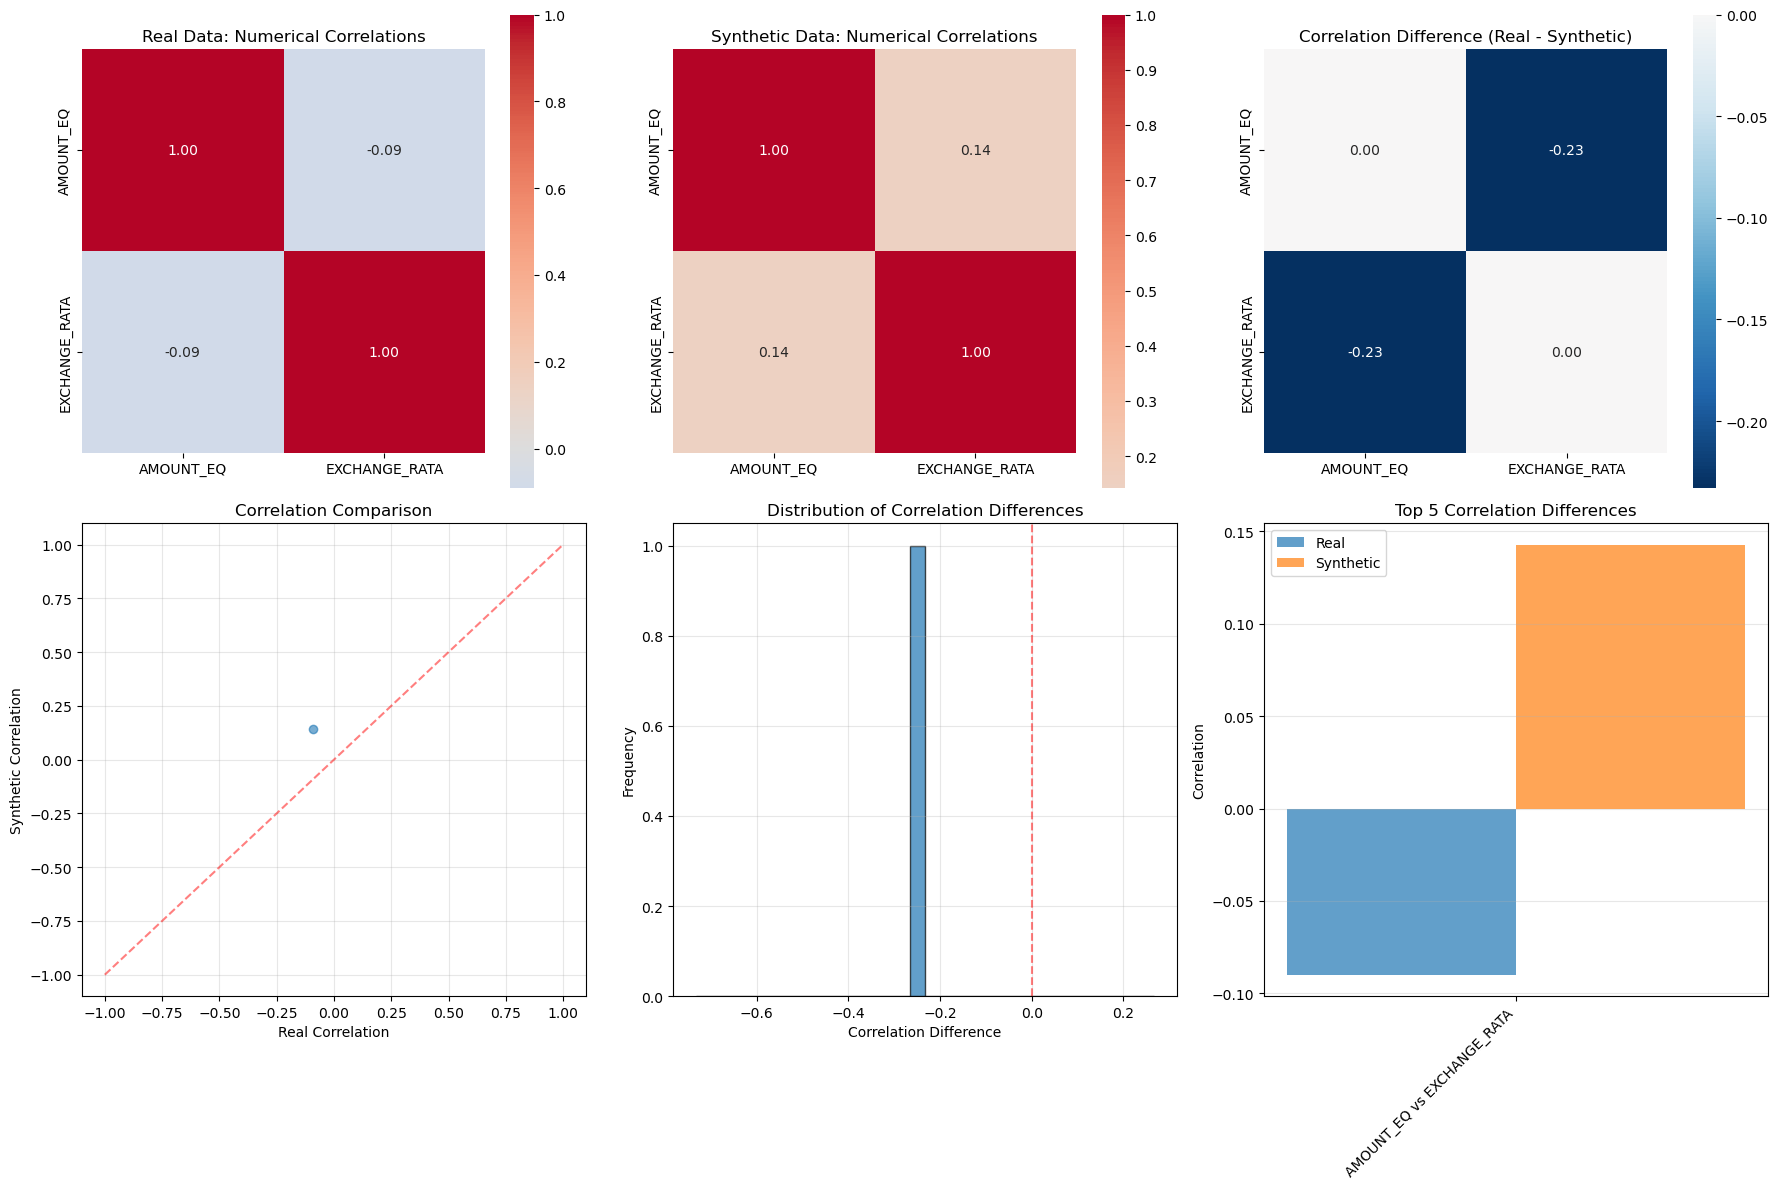


2. Categorical Feature Associations (Cramér's V):


KeyboardInterrupt: 

In [ ]:
results, summary = comprehensive_field_analysis(real_data, synth_data)